# Урок 5.3. Функции потерь для регрессии

**Интерактивная версия:** `lessons/lesson_5_3/web/index.html`

1. Что предсказывает каждая потеря: среднее, медиана, квантиль — на асимметричном шуме.
2. Предсказательный интервал и его покрытие.
3. То же в scikit-learn и LightGBM.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from gbcourse import datasets, GBRegressor
from gbcourse.plotting import use_course_style, plot_data

use_course_style()

## 1. Среднее против медианы на асимметричном шуме

Шум с тяжёлым правым хвостом (экспоненциальный): среднее выше медианы.

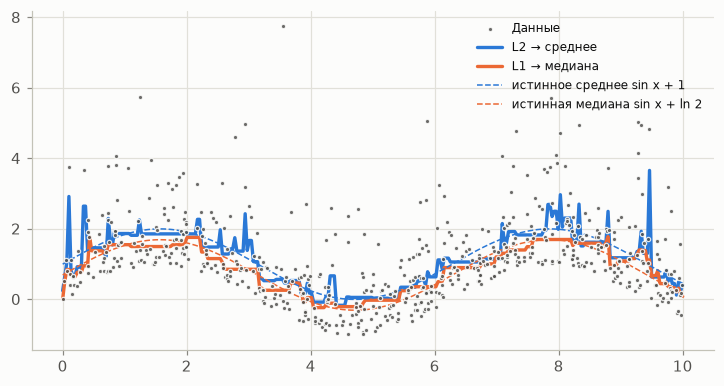

In [2]:
rng = np.random.default_rng(0)
x = np.sort(rng.uniform(0, 10, 600))
y = np.sin(x) + rng.exponential(1.0, size=x.size)
X = x.reshape(-1, 1)
grid = np.linspace(0, 10, 300).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(8, 4))
plot_data(ax, X, y, s=8)
for loss, label in [("squared", "L2 → среднее"), ("absolute", "L1 → медиана")]:
    m = GBRegressor(loss=loss, n_estimators=200, learning_rate=0.1, max_depth=2).fit(X, y)
    ax.plot(grid, m.predict(grid), lw=2.2, label=label)
ax.plot(grid, np.sin(grid) + 1.0, ls="--", color="#2a78d6", lw=1, label="истинное среднее sin x + 1")
ax.plot(grid, np.sin(grid) + np.log(2), ls="--", color="#eb6834", lw=1, label="истинная медиана sin x + ln 2")
ax.legend(fontsize=8)
plt.show()

## 2. Интервал 10–90%

пересечений квантилей: 0
покрытие на новых данных: 0.725


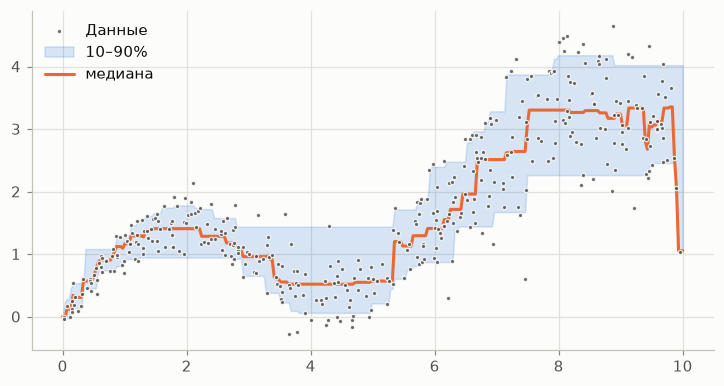

In [3]:
X, y = datasets.regression_1d(kind="hetero", n=400, noise=0.5, seed=54)
X_te, y_te = datasets.regression_1d(kind="hetero", n=3000, noise=0.5, seed=55)
models = {a: GBRegressor(loss="quantile", quantile_alpha=a, n_estimators=200, learning_rate=0.1, max_depth=2).fit(X, y)
          for a in (0.1, 0.5, 0.9)}
lo, hi = models[0.1].predict(X_te), models[0.9].predict(X_te)
print("пересечений квантилей:", int(np.sum(lo > hi)))
lo, hi = np.minimum(lo, hi), np.maximum(lo, hi)
print("покрытие на новых данных:", np.mean((y_te >= lo) & (y_te <= hi)).round(3))
fig, ax = plt.subplots(figsize=(8, 4))
plot_data(ax, X, y, s=8)
ax.fill_between(grid[:, 0], models[0.1].predict(grid), models[0.9].predict(grid), alpha=0.18, color="#2a78d6", label="10–90%")
ax.plot(grid, models[0.5].predict(grid), color="#eb6834", label="медиана")
ax.legend()
plt.show()

Покрытие по участкам x — хорошо ли интервал «следит» за шумом?

In [4]:
bins = np.linspace(0, 10, 6)
for a, b in zip(bins[:-1], bins[1:]):
    mask = (X_te[:, 0] >= a) & (X_te[:, 0] < b)
    print(f"x ∈ [{a:.0f}, {b:.0f}): покрытие {np.mean((y_te[mask] >= lo[mask]) & (y_te[mask] <= hi[mask])):.3f}, ширина {np.mean(hi[mask] - lo[mask]):.2f}")

x ∈ [0, 2): покрытие 0.761, ширина 0.54
x ∈ [2, 4): покрытие 0.741, ширина 0.91
x ∈ [4, 6): покрытие 0.694, ширина 1.25
x ∈ [6, 8): покрытие 0.760, ширина 1.64
x ∈ [8, 10): покрытие 0.673, ширина 1.83


## 3. scikit-learn и LightGBM

In [5]:
import lightgbm as lgb

sk_hi = GradientBoostingRegressor(loss="quantile", alpha=0.9, n_estimators=200, max_depth=2).fit(X, y)
lg_hi = lgb.LGBMRegressor(objective="quantile", alpha=0.9, n_estimators=200, num_leaves=4, verbose=-1).fit(X, y)
for name, m in [("gbcourse", models[0.9]), ("sklearn", sk_hi), ("LightGBM", lg_hi)]:
    print(f"{name:9s}: доля новых y ниже прогноза 0.9-квантиля = {np.mean(y_te <= m.predict(X_te)):.3f}")

gbcourse : доля новых y ниже прогноза 0.9-квантиля = 0.881
sklearn  : доля новых y ниже прогноза 0.9-квантиля = 0.845
LightGBM : доля новых y ниже прогноза 0.9-квантиля = 0.828


## Упражнения

1. Постройте покрытие интервала на новых данных в зависимости от числа деревьев (10…1000) для глубины 2 и 5.
2. Для шума с тяжёлыми хвостами (t-распределение с 2 степенями свободы) сравните MAE моделей L2, L1, Хьюбер(δ = 1).

Решения: `python lessons/lesson_5_3/exercises/solutions.py`.